In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sckitflow.methods import register_method
from sckitflow.backends.torch.nn import BaseModule
from sckitflow.data._composite import MatchedDistributions
from sckitflow.dataset.toy_data import get_toy_dataset
from sckitflow import ModelBuilder

In [ ]:
class AutoencoderModule(nn.Module):
    """Simple MLP autoencoder."""

    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int, *args, **kwargs):
        super().__init__()
        # Encoder
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*layers)

        # Decoder
        layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*layers)

    def forward(self, x):
        """"""  # noqa
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [ ]:
class AEBaseModule(BaseModule):
    """"""  # noqa

    def __init__(self, dims_registry, *args, **kwargs):
        super().__init__()
        self.input_dim = len(dims_registry.feature_names)
        self._make_modules()

    def _make_modules(self):
        self.ae = AutoencoderModule(self.input_dim, hidden_dims=[128, 64], latent_dim=16)

    def forward(self, x):
        """"""  # noqa
        return self.ae(x)

    @classmethod
    def init_from_dims_registry(cls, dims_registry, *args, **kwargs):
        """"""  # noqa
        return cls(dims_registry, *args, **kwargs)


@register_method("ae", backend="torch", category="general")
class AutoencoderMethod:
    """Autoencoder method for general reconstruction tasks."""

    module_cls = AEBaseModule

    def train_step(self, matched_distr: MatchedDistributions) -> dict[str, float]:
        """Perform a single training step.

        Args:
            matched_distr: Matched distributions containing target data.

        Returns
        -------
            Dictionary with loss value.
        """
        target_state = self._extract_state_data(matched_distr.target_distribution.state_data)
        if target_state is None:
            return {"loss": 0.0}

        recon = self.module(target_state)
        loss = nn.functional.mse_loss(recon, target_state)

        self._optimization_manager.backward_pass(loss)

        return {"loss": loss.item()}

    def predict(self, matched_distr: MatchedDistributions) -> torch.Tensor:
        """Generate reconstructions for the input data.

        Args:
            matched_distr: Matched distributions containing target data.

        Returns
        -------
            Reconstructed tensor (automatically wrapped into PredictionData by decorator).
        """
        target_state = self._extract_state_data(matched_distr.target_distribution.state_data)
        self.module.eval()
        with torch.no_grad():
            recon = self.module(target_state)
        return recon

In [ ]:
# Create synthetic AnnData
adata = get_toy_dataset("moons", noise=0.1).adata

# Instantiate the autoencoder model: prepare data, then attach the method
model = ModelBuilder.from_adata(adata).build(method_id="ae")

# Train for a few epochs (each train_step is one batch update)
model.train(adata, n_train_steps=5000, train_batch_size=128)

Predicting: 100%|██████████| 1/1 [00:00<00:00, 172.92it/s]


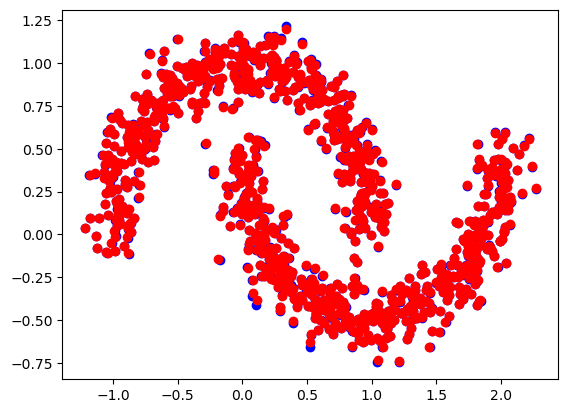

In [ ]:
# predict
adata_pred = model.predict(adata)

# visualize
plt.scatter(
    adata.X[:, 0],
    adata.X[:, 1],
    color="blue",
)
plt.scatter(adata_pred.X[:, 0], adata_pred.X[:, 1], color="red")